In [1]:
!pip install pennylane
!pip install pennylane-qiskit
!pip install torch torchvision
!pip install scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 47.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 50.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 74.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 85.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 43.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 100.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 60.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 381.8/381.8 kB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import pennylane as qml

In [3]:
DATASET_PATH = Path("/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000")

IMG_SIZE = 128
BATCH_SIZE = 64
EPOCHS = 5
NUM_QUBITS = 4
LR = 0.001

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
import os
import pandas as pd
import torch
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from sklearn.model_selection import train_test_split

DATASET_PATH = "/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000"

metadata = pd.read_csv(os.path.join(DATASET_PATH, "HAM10000_metadata.csv"))

image_dir1 = os.path.join(DATASET_PATH, "HAM10000_images_part_1")
image_dir2 = os.path.join(DATASET_PATH, "HAM10000_images_part_2")

metadata['path'] = metadata['image_id'].apply(
    lambda x: os.path.join(image_dir1, x + ".jpg")
    if os.path.exists(os.path.join(image_dir1, x + ".jpg"))
    else os.path.join(image_dir2, x + ".jpg")
)

label_dict = {
    'nv':0,
    'mel':1,
    'bkl':2,
    'bcc':3,
    'akiec':4,
    'vasc':5,
    'df':6
}

metadata['label'] = metadata['dx'].map(label_dict)

train_df, test_df = train_test_split(
    metadata,
    test_size=0.2,
    stratify=metadata['label'],
    random_state=42
)

transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor()
])

In [5]:
class SkinDataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.df = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        img_path = self.df.iloc[idx]['path']
        label = self.df.iloc[idx]['label']

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [6]:
train_dataset = SkinDataset(train_df, transform)
test_dataset = SkinDataset(test_df, transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

print("Train samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

Train samples: 8012
Test samples: 2003


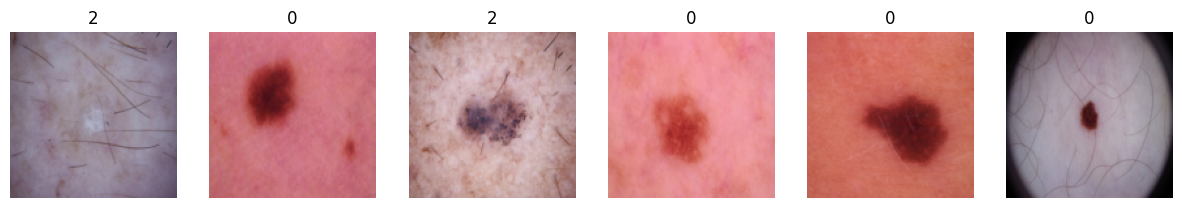

In [7]:
import matplotlib.pyplot as plt

images, labels = next(iter(train_loader))

fig, axes = plt.subplots(1,6, figsize=(15,4))

for i in range(6):
    axes[i].imshow(images[i].permute(1,2,0))
    axes[i].set_title(labels[i].item())
    axes[i].axis("off")

plt.show()

In [8]:
import torch.nn as nn

class ClassicalCNN(nn.Module):

    def __init__(self):
        super(ClassicalCNN, self).__init__()

        self.features = nn.Sequential(

            nn.Conv2d(3,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64,128,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.AdaptiveAvgPool2d((1,1))   # fixes dimension problem
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),
            nn.Linear(128,64),
            nn.ReLU(),
            nn.Linear(64,7)   # 7 skin classes
        )

    def forward(self,x):

        x = self.features(x)
        x = self.classifier(x)

        return x


model = ClassicalCNN()

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 5

train_losses = []
train_accuracies = []

for epoch in range(num_epochs):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}]  Loss: {epoch_loss:.4f}  Accuracy: {epoch_acc:.2f}%")

Epoch [1/5]  Loss: 1.1222  Accuracy: 66.20%
Epoch [2/5]  Loss: 1.0147  Accuracy: 66.90%
Epoch [3/5]  Loss: 0.9575  Accuracy: 66.96%
Epoch [4/5]  Loss: 0.9288  Accuracy: 67.36%
Epoch [5/5]  Loss: 0.9166  Accuracy: 67.51%


In [10]:
from sklearn.metrics import accuracy_score, classification_report

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())


print("Test Accuracy:", accuracy_score(all_labels, all_preds))

print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds, zero_division=0))

Test Accuracy: 0.672990514228657

Classification Report:

              precision    recall  f1-score   support

           0       0.67      1.00      0.80      1341
           1       0.00      0.00      0.00       223
           2       0.57      0.04      0.07       220
           3       0.00      0.00      0.00       103
           4       0.00      0.00      0.00        65
           5       0.00      0.00      0.00        28
           6       0.00      0.00      0.00        23

    accuracy                           0.67      2003
   macro avg       0.18      0.15      0.12      2003
weighted avg       0.51      0.67      0.55      2003



In [11]:
!pip install pennylane


In [12]:
import pennylane as qml
import torch
import torch.nn as nn

n_qubits = 4
n_layers = 2

dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev, interface="torch")
def quantum_circuit(inputs, weights):

    # Encode classical features into qubits
    qml.templates.AngleEmbedding(inputs, wires=range(n_qubits))

    # Entanglement layers
    qml.templates.BasicEntanglerLayers(weights, wires=range(n_qubits))

    # Measurement
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]



In [13]:
weight_shapes = {"weights": (n_layers, n_qubits)}

In [14]:
quantum_layer = qml.qnn.TorchLayer(quantum_circuit, weight_shapes)

In [15]:
import torch.nn as nn

class HybridModel(nn.Module):

    def __init__(self, quantum_layer):
        super(HybridModel, self).__init__()

        # CNN Feature Extractor
        self.features = nn.Sequential(

            nn.Conv2d(3,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64,128,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.AdaptiveAvgPool2d((1,1))
        )

        self.flatten = nn.Flatten()

        # Reduce CNN features → number of qubits
        self.fc1 = nn.Linear(128, n_qubits)

        # Quantum Layer
        self.quantum_layer = quantum_layer

        # Final classifier
        self.fc2 = nn.Linear(n_qubits, 7)

    def forward(self, x):

        x = self.features(x)
        x = self.flatten(x)

        x = self.fc1(x)

        x = self.quantum_layer(x)

        x = self.fc2(x)

        return x

In [16]:
model = HybridModel(quantum_layer).to(device)

In [17]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs = 3

In [18]:
for epoch in range(num_epochs):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    print(
        f"Epoch {epoch+1}/{num_epochs} "
        f"Loss: {running_loss/len(train_loader):.4f} "
        f"Accuracy: {100*correct/total:.2f}%"
    )

Epoch 1/3 Loss: 1.4568 Accuracy: 65.48%
Epoch 2/3 Loss: 1.1947 Accuracy: 66.95%
Epoch 3/3 Loss: 1.1484 Accuracy: 66.95%


In [19]:
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())


all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

print("Hybrid Model Accuracy:", accuracy_score(all_labels, all_preds))

print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds, zero_division=0))

Hybrid Model Accuracy: 0.6694957563654518

Classification Report:

              precision    recall  f1-score   support

           0       0.67      1.00      0.80      1341
           1       0.00      0.00      0.00       223
           2       0.00      0.00      0.00       220
           3       0.00      0.00      0.00       103
           4       0.00      0.00      0.00        65
           5       0.00      0.00      0.00        28
           6       0.00      0.00      0.00        23

    accuracy                           0.67      2003
   macro avg       0.10      0.14      0.11      2003
weighted avg       0.45      0.67      0.54      2003



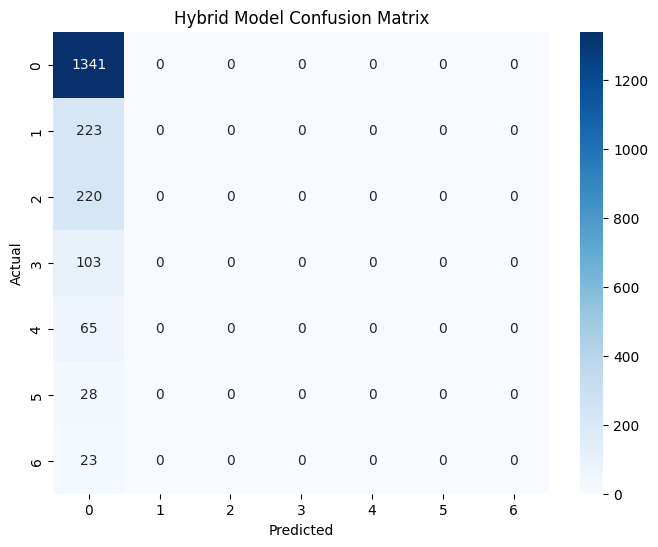

In [20]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Hybrid Model Confusion Matrix")

plt.show()

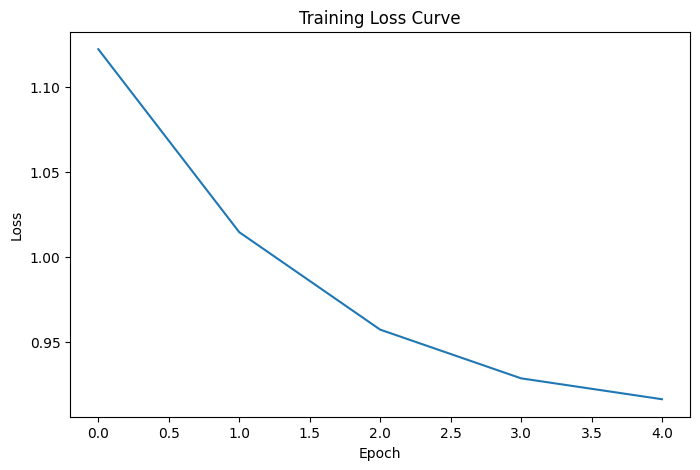

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(train_losses)
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

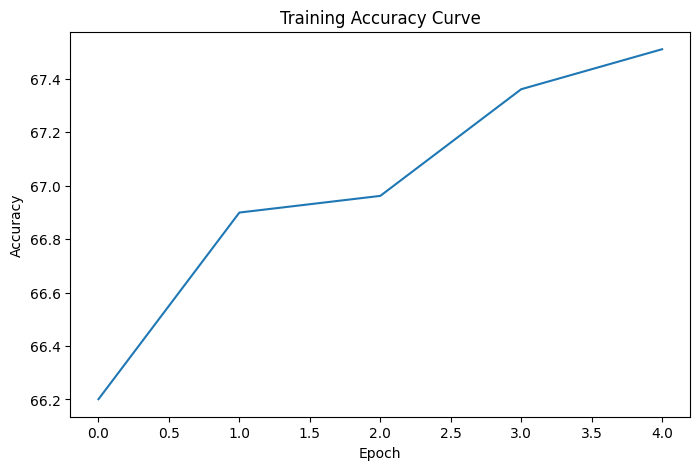

In [22]:
plt.figure(figsize=(8,5))
plt.plot(train_accuracies)
plt.title("Training Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

In [23]:
torch.save(model.state_dict(), "hybrid_skin_cancer_model.pth")

In [24]:
model.load_state_dict(torch.load("hybrid_skin_cancer_model.pth"))
model.eval()

HybridModel(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=128, out_features=4, bias=True)
  (quantum_layer): <Quantum Torch Layer: func=quantum_circuit>
  (fc2): Linear(in_features=4, out_features=7, bias=True)
)

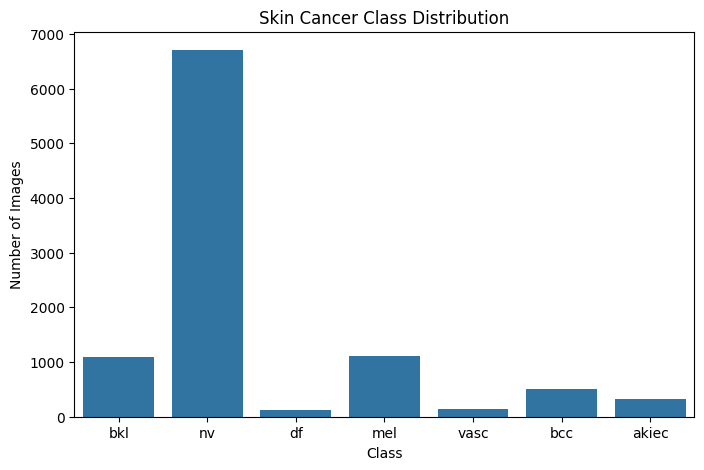

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.countplot(x=metadata['dx'])

plt.title("Skin Cancer Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.show()

In [26]:
label_names = {
0: "Melanocytic Nevi (nv)",
1: "Melanoma (mel)",
2: "Benign Keratosis (bkl)",
3: "Basal Cell Carcinoma (bcc)",
4: "Actinic Keratoses (akiec)",
5: "Vascular Lesions (vasc)",
6: "Dermatofibroma (df)"
}